## PART 1 — Import Dataset & Exploratory Data Analysis (EDA)

### Step 1 Install Required Libraries

In [1]:
!pip -q install openpyxl
!pip -q install openmeteo-requests requests-cache retry-requests
!pip -q install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\allyv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\allyv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\allyv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Step 2 Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

### Step 3 Read Dataset

In [3]:
df = pd.read_excel("DATALOG.CSV.xlsx")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


### Step 4 Rename Columns & Header Data

In [4]:
df.columns = [
    "Date",
    "Time",
    "IndoorTemp",
    "IndoorHumidity"
]

df.head()

,Date,Time,IndoorTemp,IndoorHumidity
0,2026-06-21,01:18:24,30.8,72.3
1,2026-06-21,01:18:26,30.8,72.4
2,2026-06-21,01:18:28,30.8,72.4
3,2026-06-21,01:18:30,30.8,72.4
4,2026-06-21,01:18:32,30.8,72.4


### Step 5 Create Datetime

In [5]:
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str)
    + " "
    + df["Time"].astype(str)
)
df = df.sort_values("Datetime")
df = df.reset_index(drop=True)
df.drop(columns=["Date", "Time"], inplace=True)

### Step 6 Extract Time Features

In [6]:
df["Hour"] = df["Datetime"].dt.hour
df["DayName"] = df["Datetime"].dt.day_name()
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Weekend"] = (df["DayOfWeek"] >= 5).astype(int)

### Step 7 Rearrange Column Order

In [7]:
df = df[
    [
        "Datetime",
        "Hour",
        "DayName",
        "Weekend",
        "DayOfWeek",
        "IndoorTemp",
        "IndoorHumidity"
    ]
]

### Step 8 Dataset Information

In [8]:
print("Dataset Shape")
print(df.shape)
print("\n")

print("Dataset Info")
df.info()
print("\n")

print("Missing Values")
display(df.isnull().sum())
print("\n")

print("Duplicate Rows")
print(df.duplicated().sum())
print("\n")

print("Statistical Summary")
display(df.describe())

Dataset Shape
(10257, 7)


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10257 entries, 0 to 10256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Datetime        10257 non-null  datetime64[ns]
 1   Hour            10257 non-null  int32         
 2   DayName         10257 non-null  object        
 3   Weekend         10257 non-null  int64         
 4   DayOfWeek       10257 non-null  int32         
 5   IndoorTemp      10257 non-null  float64       
 6   IndoorHumidity  10257 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(1)
memory usage: 480.9+ KB


Missing Values


Datetime          0
Hour              0
DayName           0
Weekend           0
DayOfWeek         0
IndoorTemp        0
IndoorHumidity    0
dtype: int64



Duplicate Rows
0


Statistical Summary


,Datetime,Hour,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity
count,10257,10257.000000,10257.000000,10257.000000,10257.000000,10257.000000
mean,2026-06-25 23:45:25.022716160,11.456956,0.286731,2.983328,28.292473,70.694150
min,2026-06-21 01:18:24,0.000000,0.000000,0.000000,18.600000,58.400000
25%,2026-06-24 05:11:58,5.000000,0.000000,1.000000,24.600000,66.100000
50%,2026-06-25 23:56:46,12.000000,0.000000,3.000000,30.000000,70.600000
75%,2026-06-27 18:41:39,17.000000,1.000000,5.000000,31.900000,75.300000
max,2026-06-29 13:26:36,23.000000,1.000000,6.000000,34.700000,88.600000
std,NaN,6.901237,0.452257,2.021871,4.564227,5.653743


### Step 9 Basic Visualization

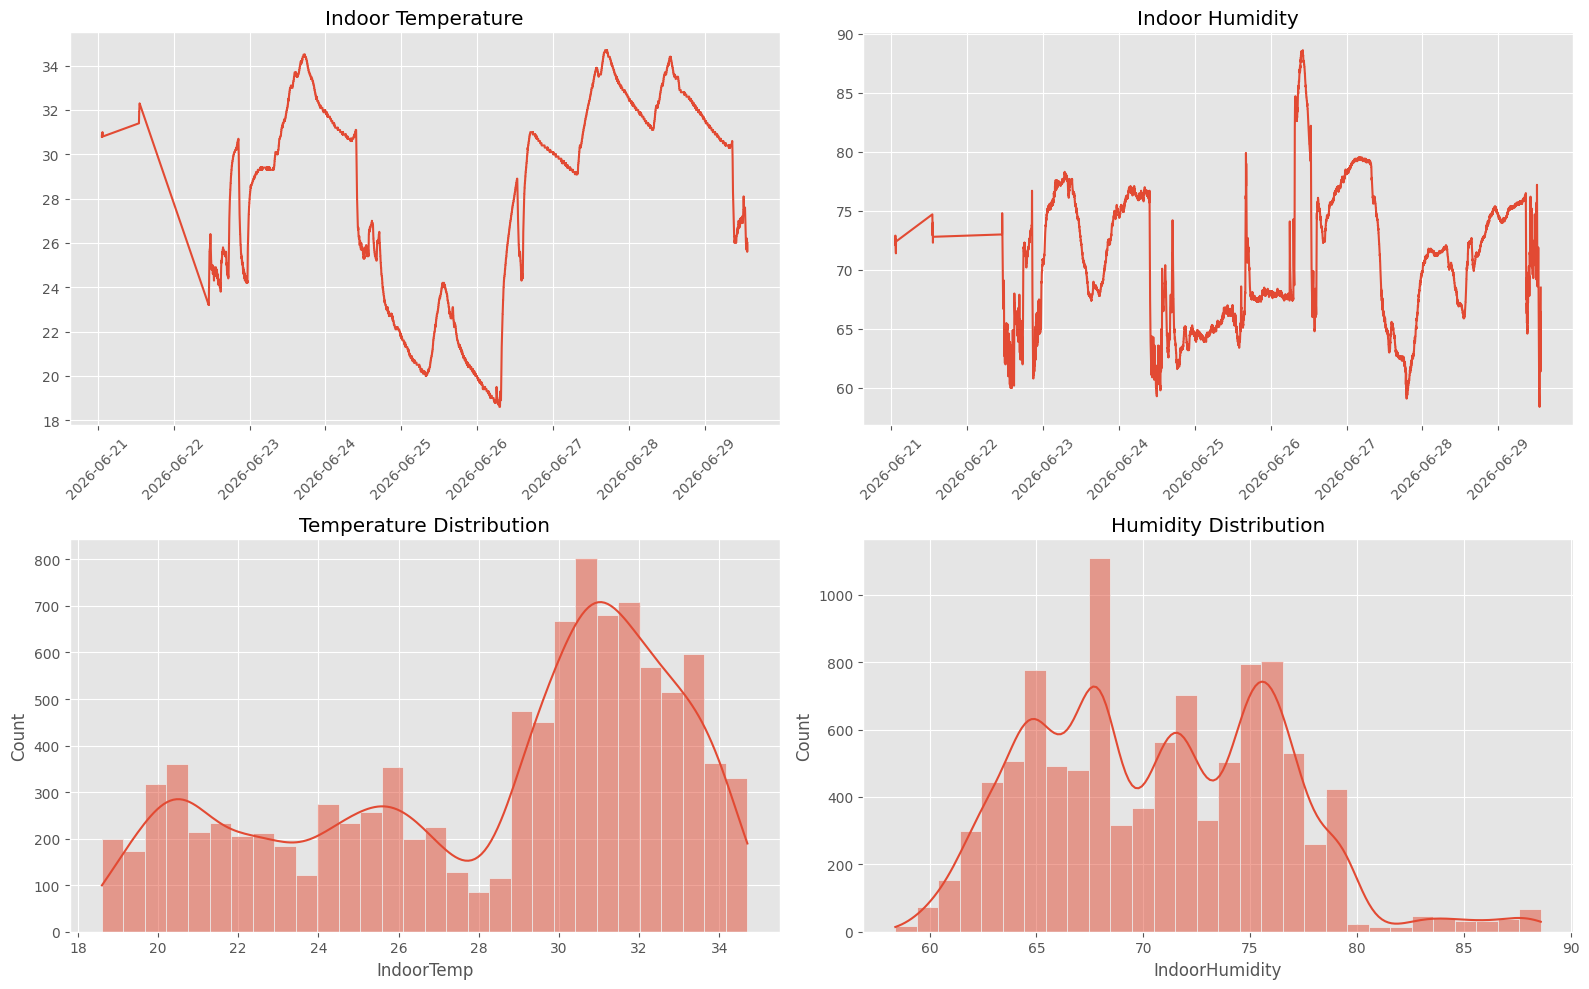

In [9]:
fig, ax = plt.subplots(2,2, figsize=(16,10))

# Indoor Temperature
ax[0,0].plot(
    df["Datetime"],
    df["IndoorTemp"]
)
ax[0,0].set_title("Indoor Temperature")
ax[0,0].tick_params(axis='x', rotation=45)

# Indoor Humidity
ax[0,1].plot(
    df["Datetime"],
    df["IndoorHumidity"]
)
ax[0,1].set_title("Indoor Humidity")
ax[0,1].tick_params(axis='x', rotation=45)

# Temperature Histogram
sns.histplot(
    df["IndoorTemp"],
    bins=30,
    kde=True,
    ax=ax[1,0]
)
ax[1,0].set_title("Temperature Distribution")

# Humidity Histogram
sns.histplot(
    df["IndoorHumidity"],
    bins=30,
    kde=True,
    ax=ax[1,1]
)
ax[1,1].set_title("Humidity Distribution")

plt.tight_layout()
plt.show()

### Step 10 Statistical Visualization

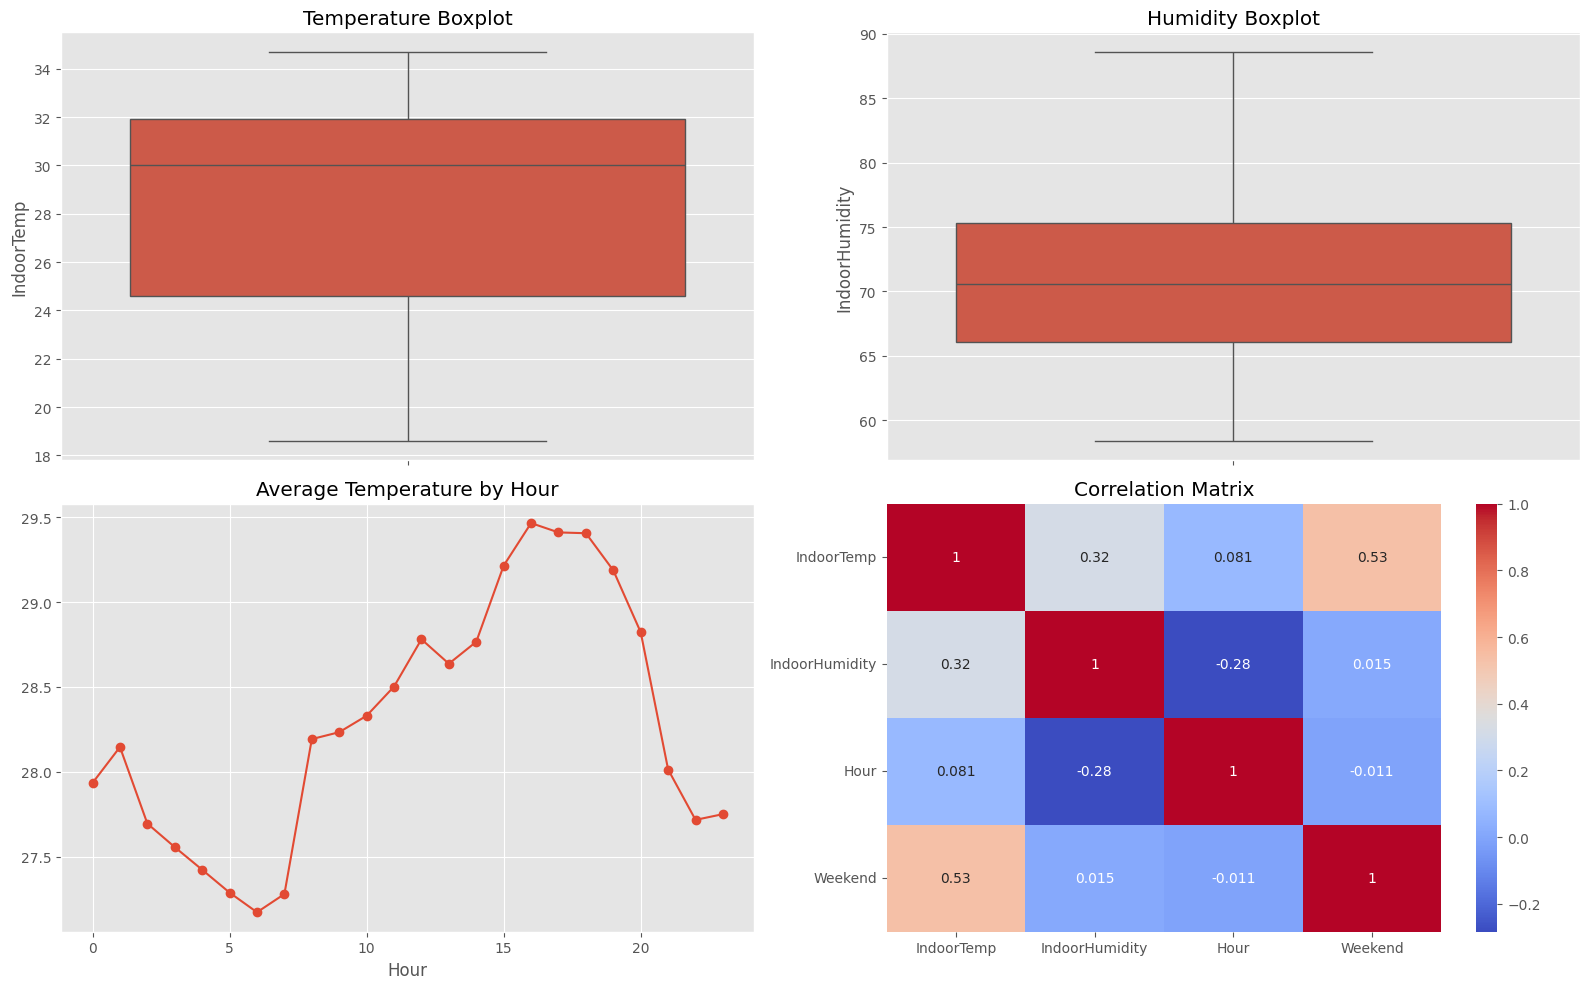

In [10]:
fig, ax = plt.subplots(2,2, figsize=(16,10))

# Temperature Boxplot
sns.boxplot(
    y=df["IndoorTemp"],
    ax=ax[0,0]
)
ax[0,0].set_title("Temperature Boxplot")

# Humidity Boxplot
sns.boxplot(
    y=df["IndoorHumidity"],
    ax=ax[0,1]
)
ax[0,1].set_title("Humidity Boxplot")

# Hourly Average Temperature
df.groupby("Hour")["IndoorTemp"].mean().plot(
    marker="o",
    ax=ax[1,0]
)
ax[1,0].set_title("Average Temperature by Hour")

# Correlation Matrix
corr = df[[
    "IndoorTemp",
    "IndoorHumidity",
    "Hour",
    "Weekend"
]].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    ax=ax[1,1]
)
ax[1,1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

### Step 11 Save Clean Dataset

In [11]:
df.to_csv(
    "Clean_Dataset.csv",
    index=False
)
print("Clean Dataset Saved Successfully!")

Clean Dataset Saved Successfully!


## PART 2 — Historical Weather Integration

### Step 1 Import Weather Libraries

In [12]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

### Step 2 Setup Open-Meteo (Weather API)

In [13]:
cache_session = requests_cache.CachedSession(
    ".cache",
    expire_after=3600
)

retry_session = retry(
    cache_session,
    retries=5,
    backoff_factor=0.2
)

client = openmeteo_requests.Client(
    session=retry_session
)

LATITUDE = 3.1728929615253114
LONGITUDE = 101.71978264862534

### Step 3 Get Date Range

In [14]:
start_date = df["Datetime"].min().strftime("%Y-%m-%d")
end_date = df["Datetime"].max().strftime("%Y-%m-%d")
print(start_date)
print(end_date)

2026-06-21
2026-06-29


### Step 4 Download Weather

In [15]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude":LATITUDE,
    "longitude":LONGITUDE,
    "start_date":start_date,
    "end_date":end_date,
    "hourly":[
        "temperature_2m",
        "relative_humidity_2m",
        "rain",
        "cloud_cover",
        "wind_speed_10m"
    ],
    "timezone":"Asia/Kuala_Lumpur"
}

response = client.weather_api(
    url,
    params=params
)[0]

### Step 5 Convert Weather to DataFrame

In [16]:
hourly = response.Hourly()
weather = pd.DataFrame({
    "Datetime":
    pd.date_range(
        start=pd.to_datetime(
            hourly.Time(),
            unit="s"
        ),
        end=pd.to_datetime(
            hourly.TimeEnd(),
            unit="s"
        ),
        freq=pd.Timedelta(
            seconds=hourly.Interval()
        ),
        inclusive="left"
    ),
    "OutdoorTemp":
    hourly.Variables(0).ValuesAsNumpy(),
    "OutdoorHumidity":
    hourly.Variables(1).ValuesAsNumpy(),
    "Rain":
    hourly.Variables(2).ValuesAsNumpy(),
    "CloudCover":
    hourly.Variables(3).ValuesAsNumpy(),
    "WindSpeed":
    hourly.Variables(4).ValuesAsNumpy()
})

weather.head()

,Datetime,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-20 16:00:00,25.049999,95.903397,0.2,90.0,6.519877
1,2026-06-20 17:00:00,25.250000,90.047913,0.0,95.0,7.059122
2,2026-06-20 18:00:00,25.750000,95.924232,0.0,73.0,1.405845
3,2026-06-20 19:00:00,25.450001,94.775391,0.0,80.0,3.864763
4,2026-06-20 20:00:00,24.700001,96.470406,0.3,94.0,4.680000


### Step 6 Time Interpolation

In [17]:
weather["Datetime"] = pd.to_datetime(weather["Datetime"])
weather = weather.set_index("Datetime")
weather = weather.resample("1min").interpolate()
weather = weather.reset_index()

### Step 7 Merge

In [18]:
df = pd.merge_asof(
    df.sort_values("Datetime"),
    weather.sort_values("Datetime"),
    on="Datetime",
    direction="nearest"
)

### Step 8 Check Missing Values

In [19]:
display(
    df[[
        "OutdoorTemp",
        "OutdoorHumidity",
        "Rain",
        "CloudCover",
        "WindSpeed"
    ]].isnull().sum()
)

OutdoorTemp        0
OutdoorHumidity    0
Rain               0
CloudCover         0
WindSpeed          0
dtype: int64

### Step 9 Dataset Preview

In [20]:
display(df.head())

,Datetime,Hour,DayName,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-21 01:18:24,1,Sunday,1,6,30.8,72.3,27.595001,83.465576,0.0,88.199997,2.199785
1,2026-06-21 01:18:26,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.199997,2.199785
2,2026-06-21 01:18:28,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.199997,2.199785
3,2026-06-21 01:18:30,1,Sunday,1,6,30.8,72.4,27.595001,83.465576,0.0,88.199997,2.199785
4,2026-06-21 01:18:32,1,Sunday,1,6,30.8,72.4,27.630835,83.283875,0.0,87.933334,2.185981


### Step 10 Weather, Temperature and Humidity Visualization

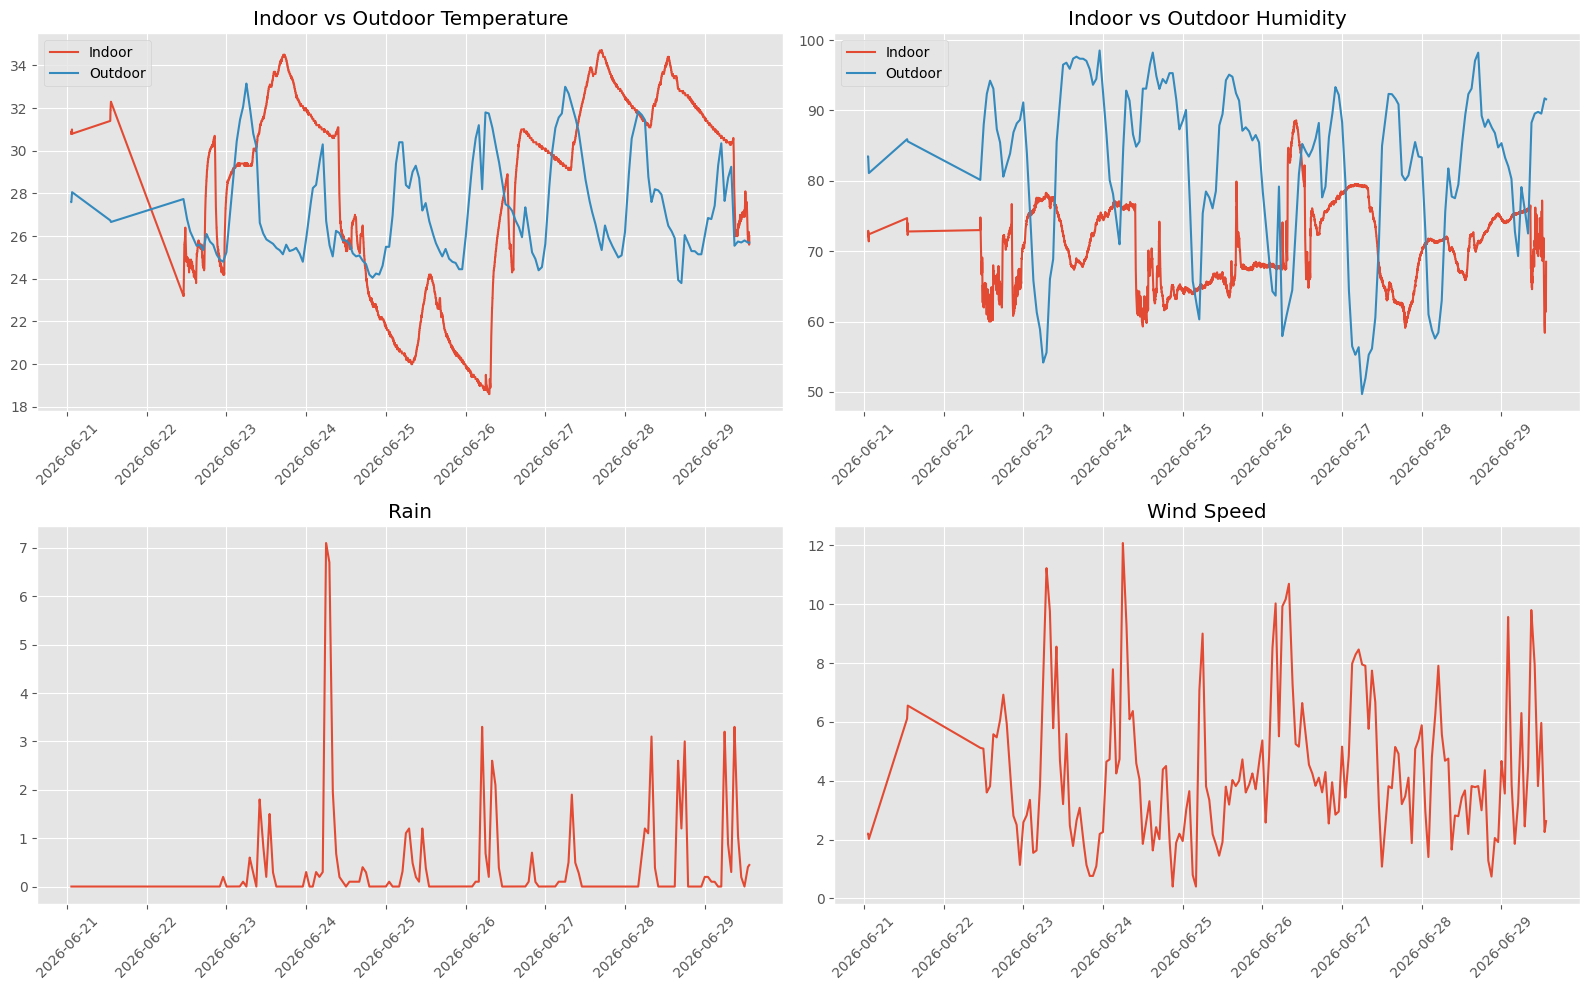

In [21]:
fig, ax = plt.subplots(2,2, figsize=(16,10))

# Indoor vs Outdoor Temperature
ax[0,0].plot(
    df["Datetime"],
    df["IndoorTemp"],
    label="Indoor"
)
ax[0,0].plot(
    df["Datetime"],
    df["OutdoorTemp"],
    label="Outdoor"
)
ax[0,0].legend()
ax[0,0].set_title("Indoor vs Outdoor Temperature")
ax[0,0].tick_params(axis='x', rotation=45)

# Indoor vs Outdoor Humidity
ax[0,1].plot(
    df["Datetime"],
    df["IndoorHumidity"],
    label="Indoor"
)
ax[0,1].plot(
    df["Datetime"],
    df["OutdoorHumidity"],
    label="Outdoor"
)
ax[0,1].legend()
ax[0,1].set_title("Indoor vs Outdoor Humidity")
ax[0,1].tick_params(axis='x', rotation=45)

# Rain
ax[1,0].plot(
    df["Datetime"],
    df["Rain"]
)
ax[1,0].set_title("Rain")
ax[1,0].tick_params(axis='x', rotation=45)

# Wind Speed
ax[1,1].plot(
    df["Datetime"],
    df["WindSpeed"]
)
ax[1,1].set_title("Wind Speed")
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Step 11 Save Weather Dataset

In [22]:
df.to_csv(
    "Weather_Integrated_Dataset.csv",
    index=False
)
print("Weather data successfully integrated!")

Weather data successfully integrated!
